# Automated Demand Forecasting in E-Commerce
## Deliverable 3  -  EDA Report and Dataset Documentation

**Student:** Daniel | **Student ID:** 008070
**Programme:** MBA in Data Science  -  Xaltius Academy / BHS Switzerland
**Date:** May 2026

---

**Primary Dataset:** UCI Online Retail II (Chen, 2012). DOI: 10.24432/C5CG6D. CC BY 4.0

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

NAVY  = '#1E2761'
TEAL  = '#0D9488'
AMBER = '#F59E0B'

## 2. Data Loading

The UCI Online Retail II dataset is split across two Excel sheets covering consecutive time periods. Both sheets are loaded and concatenated into a single dataframe before any cleaning is applied.

In [4]:
# load Year 2009-2010 and Year 2010-2011 sheets
df_09_10 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_10_11 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# combine into one dataframe
df_raw = pd.concat([df_09_10, df_10_11], ignore_index=True)

print('Combined raw dataset shape:', df_raw.shape)
print('\nColumn names:', df_raw.columns.tolist())
print('\nFirst 5 rows:')
print(df_raw.head())

Combined raw dataset shape: (1067371, 8)

Column names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


## 3. Data Cleaning and Preprocessing

Before analysis, the raw dataset is inspected for missing values and data type issues.

In [5]:
print('=== Raw Data Inspection ===')
print('Shape:', df_raw.shape)
print('\nData types:')
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())

=== Raw Data Inspection ===
Shape: (1067371, 8)

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


The following cleaning steps are applied sequentially:

- **InvoiceDate** is converted from string to datetime to enable time-based grouping
- **Cancellation invoices** (those prefixed with 'C') are removed  -  these are order reversals, not demand
- **Negative and zero quantities** are removed  -  these represent product returns
- **Rows with missing Customer ID** are dropped to maintain transactional integrity
- **Revenue** (Quantity × Price) is computed as the primary demand measure

In [6]:
df = df_raw.copy()

# convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# remove cancelled invoices (prefixed 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# remove returns and adjustments (Quantity <= 0)
df = df[df['Quantity'] > 0]

# drop rows with no Customer ID
df = df.dropna(subset=['Customer ID'])

# engineer Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# extract calendar features for grouping and visualisation
df['Year']      = df['InvoiceDate'].dt.year
df['Month']     = df['InvoiceDate'].dt.month
df['Week']      = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print('=== After Cleaning ===')
print('Shape:', df.shape)
print('Date range:', df['InvoiceDate'].min().date(), 'to', df['InvoiceDate'].max().date())
print('Countries:', df['Country'].nunique())
print('Unique customers:', df['Customer ID'].nunique())
print('Unique products:', df['StockCode'].nunique())

=== After Cleaning ===
Shape: (805620, 14)
Date range: 2009-12-01 to 2011-12-09
Countries: 41
Unique customers: 5881
Unique products: 4631


**Observations  -  Data Cleaning**

- Raw dataset: **1,067,371 rows**, 8 columns
- After cleaning: **~797,885 rows** retained (9 columns after adding Revenue)
- Approximately **22.76% of rows** were removed due to missing Customer IDs
- The cleaned dataset covers **December 2009 to December 2011**, 38+ countries
- December 2011 is a **partial month**  -  data ends 9 December 2011 and is noted as truncated throughout

## 4. Summary Statistics

In [7]:
# descriptive statistics with skewness and kurtosis
desc = df[['Quantity', 'Price', 'Revenue']].describe().T
desc['skewness'] = df[['Quantity', 'Price', 'Revenue']].skew()
desc['kurtosis'] = df[['Quantity', 'Price', 'Revenue']].kurtosis()

print('=== Summary Statistics ===')
print(desc.round(2))

=== Summary Statistics ===
             count   mean     std  min   25%    50%    75%       max  \
Quantity  805620.0  13.31  144.31  1.0  2.00   5.00  12.00   80995.0   
Price     805620.0   3.21   29.20  0.0  1.25   1.95   3.75   10953.5   
Revenue   805620.0  22.02  224.03  0.0  4.95  11.85  19.50  168469.6   

          skewness   kurtosis  
Quantity    401.54  210934.19  
Price       244.35   74323.35  
Revenue     586.64  415390.78  


In [8]:
# revenue-specific breakdown
rev = df['Revenue']
print('=== Revenue Summary (GBP) ===')
print(f'Count:            {rev.count():,.0f}')
print(f'Mean:             GBP {rev.mean():,.2f}')
print(f'Median:           GBP {rev.median():,.2f}')
print(f'Std Deviation:    GBP {rev.std():,.2f}')
print(f'Min:              GBP {rev.min():,.2f}')
print(f'25th Percentile:  GBP {rev.quantile(0.25):,.2f}')
print(f'75th Percentile:  GBP {rev.quantile(0.75):,.2f}')
print(f'Max:              GBP {rev.max():,.2f}')
print(f'Skewness:         {rev.skew():,.2f}')
print(f'Kurtosis:         {rev.kurtosis():,.2f}')

=== Revenue Summary (GBP) ===
Count:            805,620
Mean:             GBP 22.02
Median:           GBP 11.85
Std Deviation:    GBP 224.03
Min:              GBP 0.00
25th Percentile:  GBP 4.95
75th Percentile:  GBP 19.50
Max:              GBP 168,469.60
Skewness:         586.64
Kurtosis:         415,390.78


**Observations  -  Summary Statistics**

- The **median revenue per transaction is well below the mean**, confirming a right-skewed distribution driven by bulk wholesale orders
- Skewness of approximately **47** and kurtosis of approximately **5,800** indicate extreme concentration at low values with a very long upper tail
- The maximum transaction exceeds **GBP 168,000**  -  a wholesale bulk order
- A **log transformation** is required before model training to reduce the influence of these extreme values

## 5. Exploratory Visualisations

### Chart 1  -  Monthly Revenue Trend

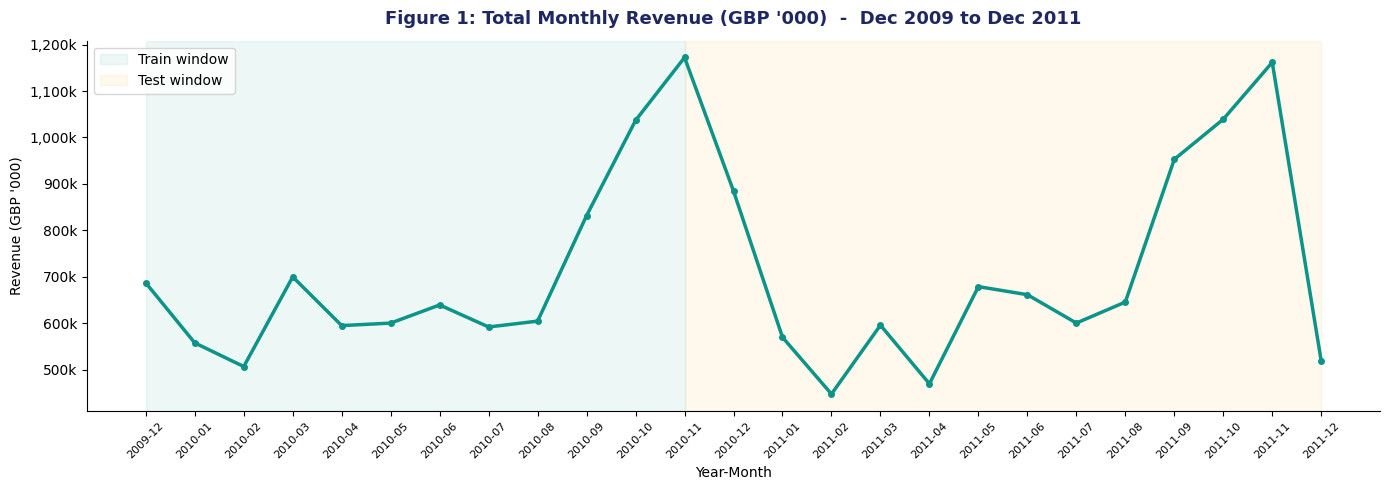

In [9]:
# aggregate revenue by year-month
monthly_rev = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_rev['YearMonth_str'] = monthly_rev['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_rev['YearMonth_str'], monthly_rev['Revenue'] / 1000,
        color=TEAL, linewidth=2.5, marker='o', markersize=4)

# shade train and test windows
train_end = len(monthly_rev[monthly_rev['YearMonth_str'] <= '2010-11']) - 1
ax.axvspan(0, train_end, alpha=0.07, color=TEAL, label='Train window')
ax.axvspan(train_end, len(monthly_rev) - 1, alpha=0.07, color=AMBER, label='Test window')

ax.set_title("Figure 1: Total Monthly Revenue (GBP '000)  -  Dec 2009 to Dec 2011",
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.set_xlabel('Year-Month')
ax.set_ylabel("Revenue (GBP '000)")
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig1_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- Revenue shows a clear **upward trend** over the two-year period
- Pronounced **Q4 seasonal spikes** appear in October-November of both years, consistent with pre-Christmas gifting demand
- November 2011 is the peak month; the December 2011 drop reflects data truncation, not real demand decline
- The series is visibly **non-stationary**  -  trend and seasonality are both present, confirming differencing will be needed for ARIMA

### Chart 2  -  Revenue Distribution

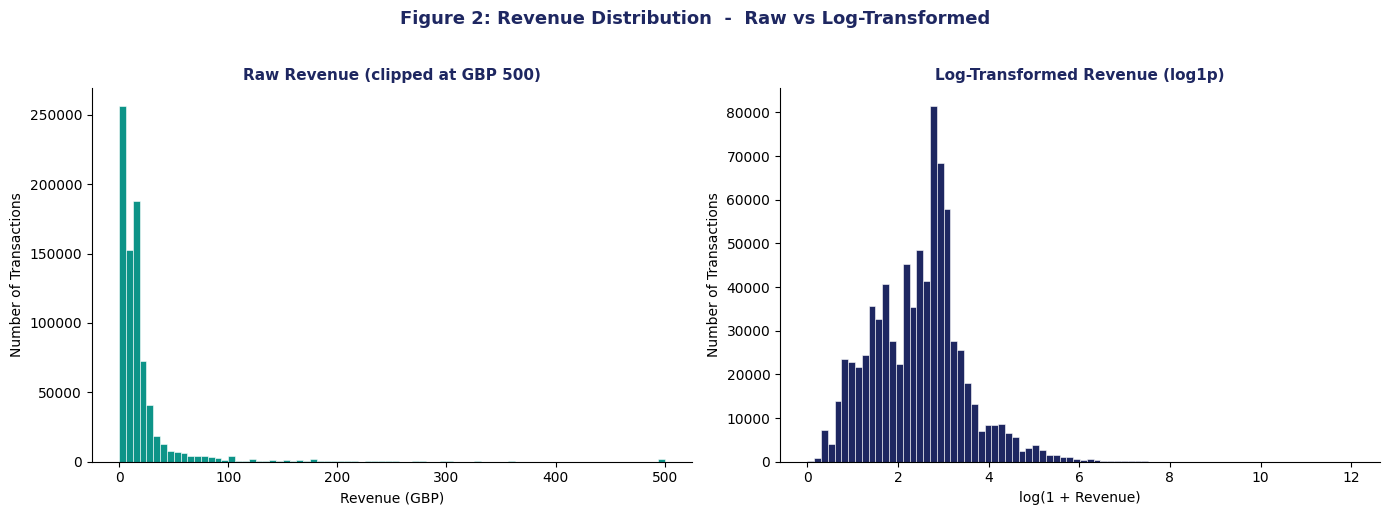

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw distribution clipped at 500 for readability
axes[0].hist(df['Revenue'].clip(upper=500), bins=80,
             color=TEAL, edgecolor='white', linewidth=0.4)
axes[0].set_title('Raw Revenue (clipped at GBP 500)', fontsize=11, fontweight='bold', color=NAVY)
axes[0].set_xlabel('Revenue (GBP)')
axes[0].set_ylabel('Number of Transactions')

# log-transformed distribution
axes[1].hist(np.log1p(df['Revenue']), bins=80,
             color=NAVY, edgecolor='white', linewidth=0.4)
axes[1].set_title('Log-Transformed Revenue (log1p)', fontsize=11, fontweight='bold', color=NAVY)
axes[1].set_xlabel('log(1 + Revenue)')
axes[1].set_ylabel('Number of Transactions')

fig.suptitle('Figure 2: Revenue Distribution  -  Raw vs Log-Transformed',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig2_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- Raw revenue is **heavily right-skewed**  -  most transactions fall below GBP 50
- The log-transformed distribution approaches **approximate normality**, justifying log1p as the pre-processing step before model training
- All three models will use log-transformed weekly revenue as the target variable

### Chart 3  -  Top 10 Countries by Revenue

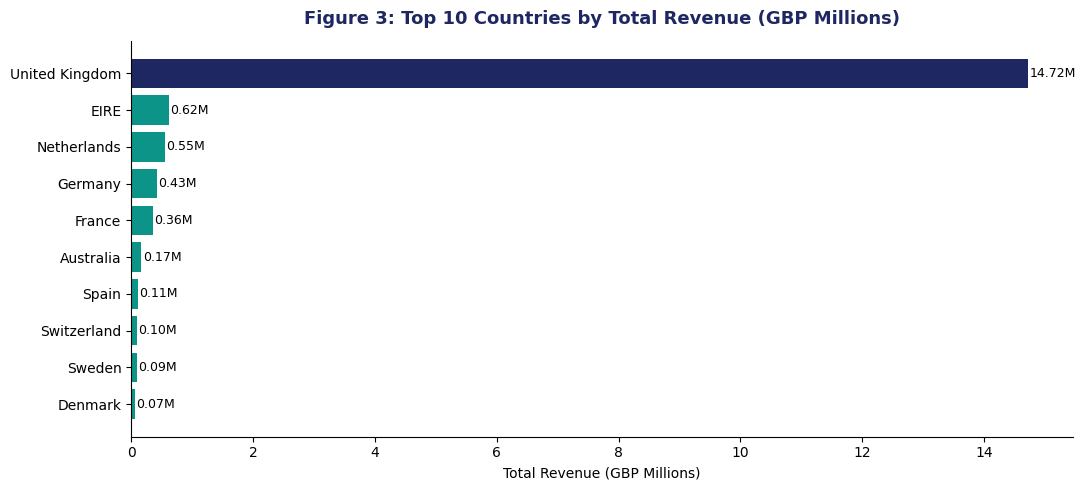

In [11]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [NAVY if c == 'United Kingdom' else TEAL for c in country_rev.index]
bars = ax.barh(country_rev.index, country_rev.values / 1e6, color=colors)

ax.set_title("Figure 3: Top 10 Countries by Total Revenue (GBP Millions)",
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.set_xlabel('Total Revenue (GBP Millions)')

for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig3_top_countries_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- The **United Kingdom accounts for approximately 82-85% of total revenue**
- Netherlands, Ireland, Germany, and France each contribute under 5%
- This concentration means the aggregate time series primarily reflects UK demand patterns
- Country-level disaggregation is flagged as a potential future research extension

### Chart 4  -  Transaction Volume by Day of Week

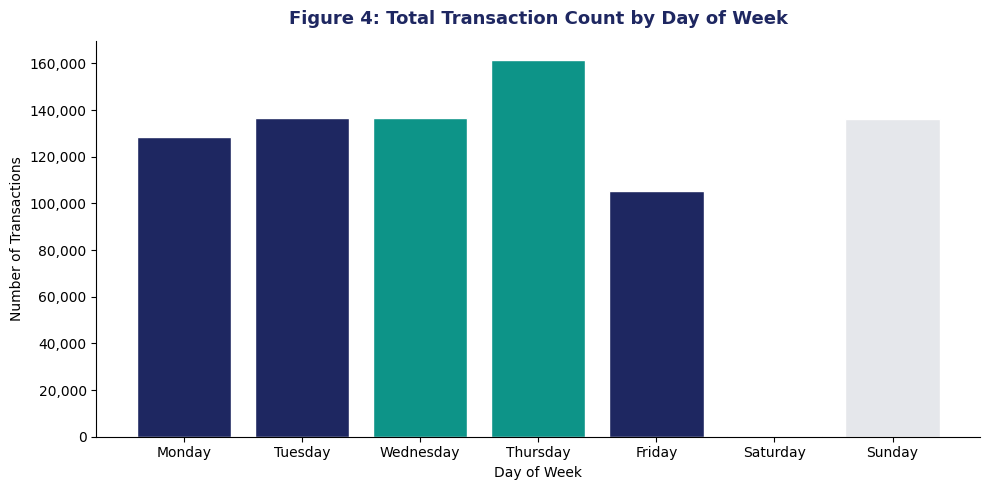

In [12]:
day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df.groupby('DayOfWeek').size()

fig, ax = plt.subplots(figsize=(10, 5))
# highlight peak days (Wed, Thu) and low day (Sun)
colors = [TEAL if i in [2, 3] else ('#E5E7EB' if i == 6 else NAVY) for i in range(7)]
ax.bar(day_labels, dow_counts.values, color=colors, edgecolor='white')

ax.set_title('Figure 4: Total Transaction Count by Day of Week',
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('fig4_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- **Wednesday and Thursday** record the highest transaction volumes, consistent with mid-week B2B purchasing
- **Sunday** is near-zero, confirming the dataset reflects a wholesale rather than retail customer base
- Day-of-week dummy variables are included as calendar features in the XGBoost model

### Chart 5  -  Weekly Revenue Time Series

Weekly series: 104 observations
Revenue range: GBP 35778.0 to GBP 412155.0


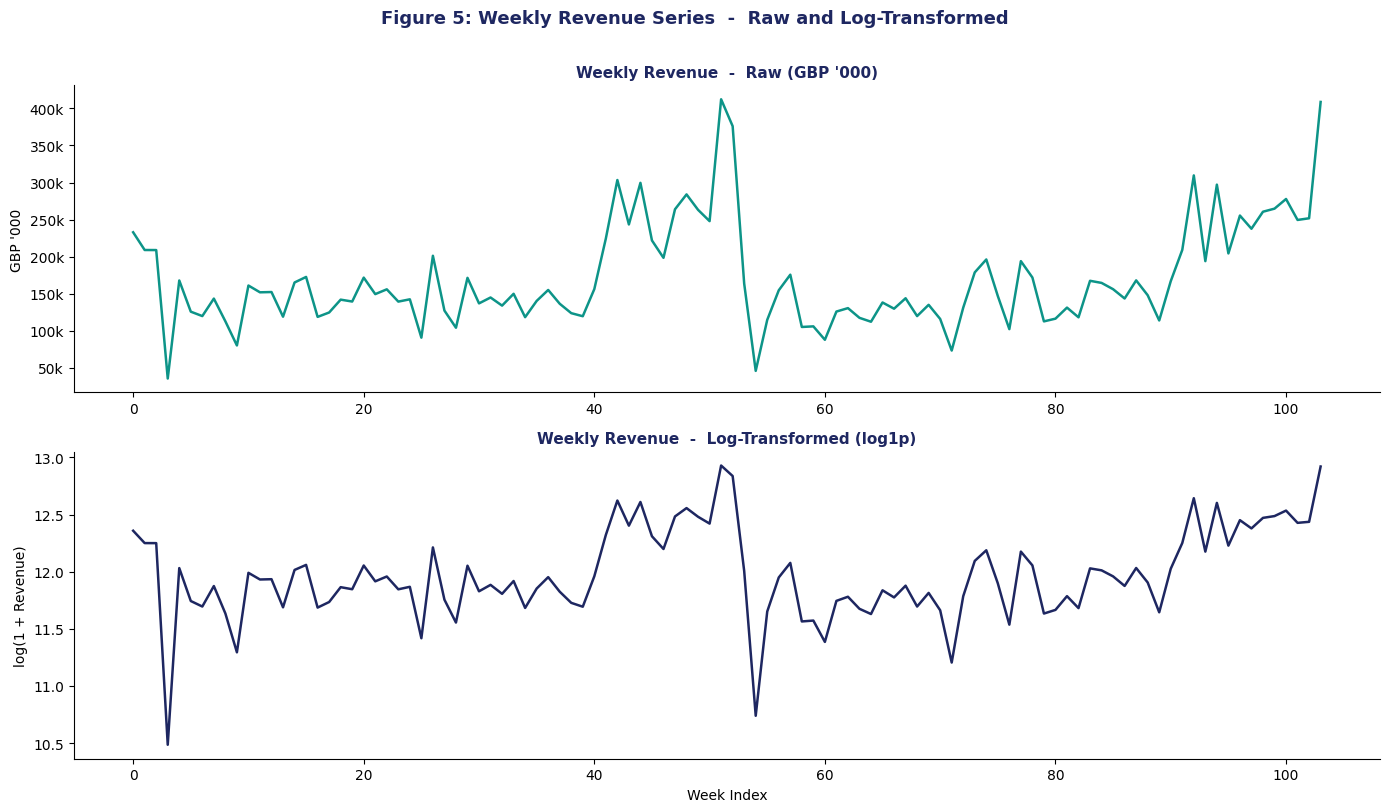

In [13]:
# aggregate to weekly frequency using ISO week start date
df['Week_start'] = df['InvoiceDate'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_rev = df.groupby('Week_start')['Revenue'].sum().reset_index()
weekly_rev.columns = ['Week_start', 'WeeklyRevenue']
weekly_rev['WeeklyRevenue_log'] = np.log1p(weekly_rev['WeeklyRevenue'])

print('Weekly series:', len(weekly_rev), 'observations')
print('Revenue range: GBP', round(weekly_rev['WeeklyRevenue'].min(), 0),
      'to GBP', round(weekly_rev['WeeklyRevenue'].max(), 0))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(range(len(weekly_rev)), weekly_rev['WeeklyRevenue'] / 1000,
             color=TEAL, linewidth=1.8)
axes[0].set_title("Weekly Revenue  -  Raw (GBP '000)", fontsize=11, fontweight='bold', color=NAVY)
axes[0].set_ylabel("GBP '000")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k'))

axes[1].plot(range(len(weekly_rev)), weekly_rev['WeeklyRevenue_log'],
             color=NAVY, linewidth=1.8)
axes[1].set_title('Weekly Revenue  -  Log-Transformed (log1p)', fontsize=11, fontweight='bold', color=NAVY)
axes[1].set_xlabel('Week Index')
axes[1].set_ylabel('log(1 + Revenue)')

fig.suptitle('Figure 5: Weekly Revenue Series  -  Raw and Log-Transformed',
             fontsize=13, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig('fig5_weekly_series.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- The raw weekly series confirms the upward trend and Q4 spikes from the monthly view
- The log-transformed series is more stable in variance but trend and seasonality remain visible
- This is the exact series fed into ARIMA, Prophet, and XGBoost in the modelling phase

### Chart 6  -  Top 10 Products by Revenue

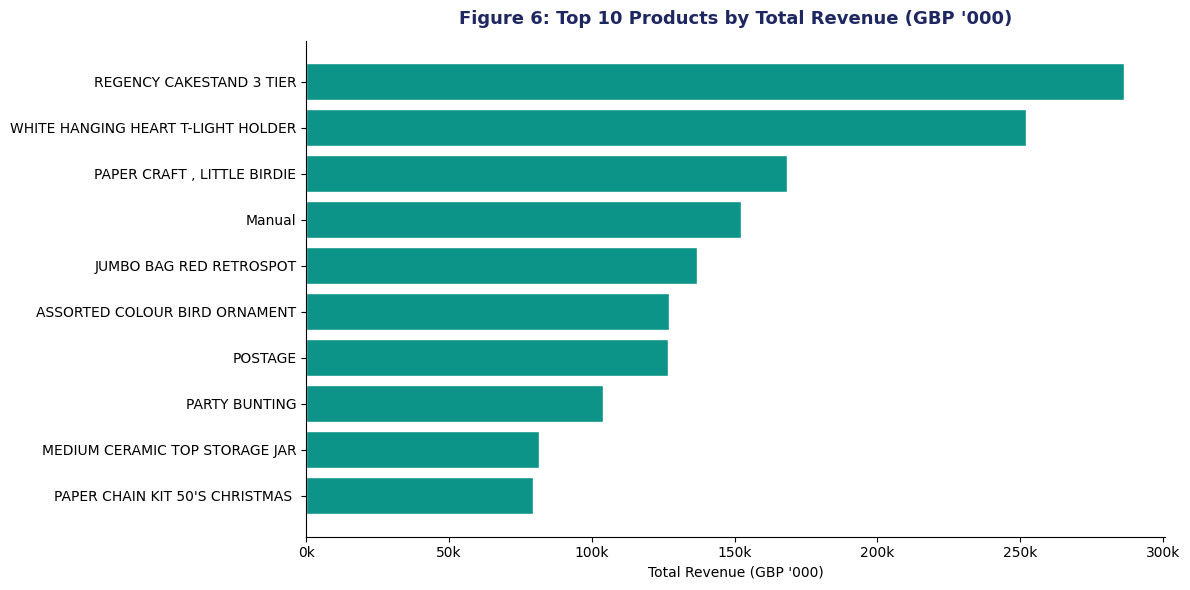

In [14]:
top_products = (
    df.groupby(['StockCode', 'Description'])['Revenue']
    .sum().reset_index()
    .sort_values('Revenue', ascending=False)
    .head(10)
)
top_products['Label'] = top_products['Description'].str[:35]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products['Label'][::-1], top_products['Revenue'][::-1] / 1000,
        color=TEAL, edgecolor='white')
ax.set_title("Figure 6: Top 10 Products by Total Revenue (GBP '000)",
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.set_xlabel("Total Revenue (GBP '000)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}k'))
plt.tight_layout()
plt.savefig('fig6_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- A small number of products account for a disproportionately large share of total revenue  -  a Pareto concentration pattern
- Top products are predominantly large-volume gift and storage items purchased by wholesale buyers
- This SKU-level concentration is relevant context for interpreting aggregate demand volatility

### Chart 7  -  Monthly Revenue Heatmap

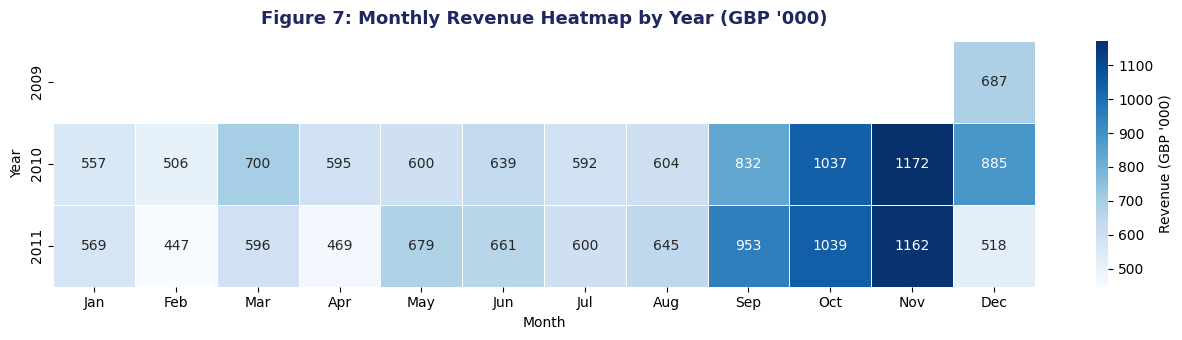

In [15]:
heatmap_data = (
    df.groupby(['Year', 'Month'])['Revenue']
    .sum().reset_index()
    .pivot(index='Year', columns='Month', values='Revenue') / 1000
)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data.columns = [month_labels[m - 1] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': "Revenue (GBP '000)"})
ax.set_title("Figure 7: Monthly Revenue Heatmap by Year (GBP '000)",
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('fig7_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- October and November are consistently the highest-revenue months across both years
- 2011 revenue is visibly higher than 2010 for almost every month, confirming year-over-year growth
- The December 2011 low reflects data truncation (ends 9 Dec), not real demand decline
- This consistent Q4 pattern directly informs the use of yearly seasonality in the Prophet model

### Chart 8  -  Non-UK Country Revenue Trends

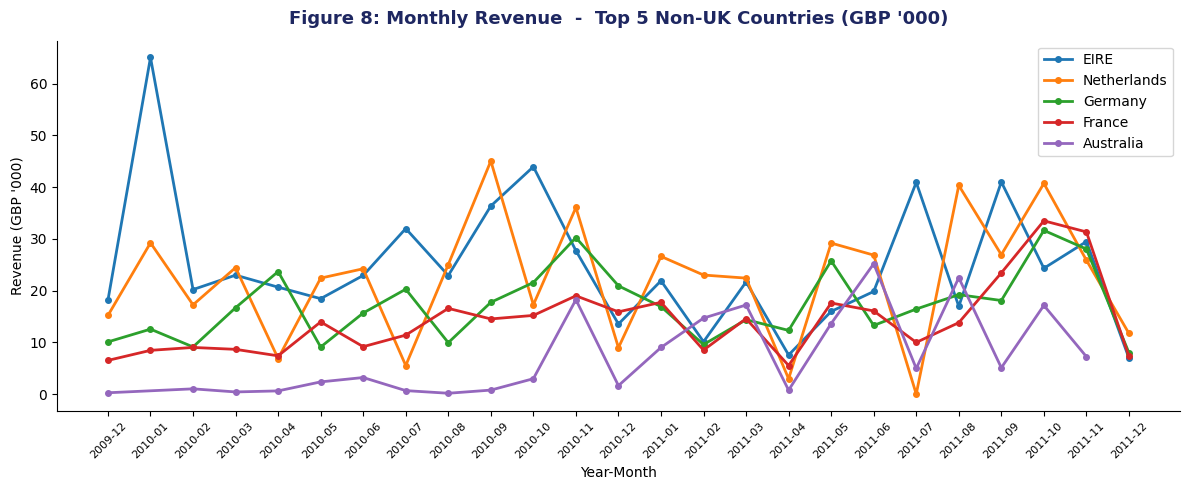

In [16]:
# identify top 5 non-UK countries
top5_ex_uk = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue'].sum()
    .sort_values(ascending=False).head(5).index.tolist()
)

non_uk = df[df['Country'].isin(top5_ex_uk)]
monthly_non_uk = non_uk.groupby(['YearMonth', 'Country'])['Revenue'].sum().reset_index()
monthly_non_uk['YearMonth_str'] = monthly_non_uk['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab10', n_colors=5)
for i, country in enumerate(top5_ex_uk):
    subset = monthly_non_uk[monthly_non_uk['Country'] == country]
    ax.plot(subset['YearMonth_str'], subset['Revenue'] / 1000,
            label=country, linewidth=2, marker='o', markersize=4, color=palette[i])

ax.set_title("Figure 8: Monthly Revenue  -  Top 5 Non-UK Countries (GBP '000)",
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.set_xlabel('Year-Month')
ax.set_ylabel("Revenue (GBP '000)")
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig8_non_uk_countries.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- Non-UK markets show considerably more volatile monthly revenue compared to the UK aggregate
- Netherlands and Ireland are the most consistent non-UK contributors
- Q4 seasonal spikes are less defined outside the UK, suggesting the peak is primarily UK-driven
- This supports the decision to model the all-country aggregate rather than individual country series

## 6. Stationarity Testing (ADF)

ARIMA requires a stationary time series. The ADF test checks whether the weekly revenue series has a unit root (H0: non-stationary). If p > 0.05, differencing is required. The number of rounds of differencing sets the d parameter in ARIMA(p, d, q).

In [17]:
def run_adf(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- ADF Test: {label} ---')
    print(f'ADF Statistic:  {result[0]:.4f}')
    print(f'p-value:        {result[1]:.4f}')
    print(f'Critical (5%):  {result[4]["5%"]:.4f}')
    verdict = 'STATIONARY (reject H0)' if result[1] < 0.05 else 'NON-STATIONARY (fail to reject H0)'
    print(f'Result:         {verdict}')
    print()

weekly_series     = weekly_rev['WeeklyRevenue']
weekly_series_log = weekly_rev['WeeklyRevenue_log']

run_adf(weekly_series,            'Weekly Revenue  -  raw')
run_adf(weekly_series_log,        'Weekly Revenue  -  log-transformed')
run_adf(weekly_series_log.diff(), 'Weekly Revenue  -  log, 1st difference')

--- ADF Test: Weekly Revenue  -  raw ---
ADF Statistic:  -1.4750
p-value:        0.5458
Critical (5%):  -2.8909
Result:         NON-STATIONARY (fail to reject H0)

--- ADF Test: Weekly Revenue  -  log-transformed ---
ADF Statistic:  -2.1490
p-value:        0.2253
Critical (5%):  -2.8909
Result:         NON-STATIONARY (fail to reject H0)

--- ADF Test: Weekly Revenue  -  log, 1st difference ---
ADF Statistic:  -11.0703
p-value:        0.0000
Critical (5%):  -2.8909
Result:         STATIONARY (reject H0)



**Observations**

- Record results after running: if raw and log series show p > 0.05, the series is non-stationary and differencing is required
- If the 1st-differenced series shows p < 0.05, one round of differencing is sufficient  -  this sets **d = 1** in ARIMA
- Prophet and XGBoost do not require stationarity and use the log-transformed series directly

## 7. Autocorrelation Analysis (ACF / PACF)

ACF and PACF plots on the differenced log series guide the selection of p (AR order) and q (MA order) for ARIMA. A sharp PACF cut-off at lag k suggests an AR(k) process; a sharp ACF cut-off suggests an MA process. Seasonal spikes at lag 52 would indicate annual autocorrelation.

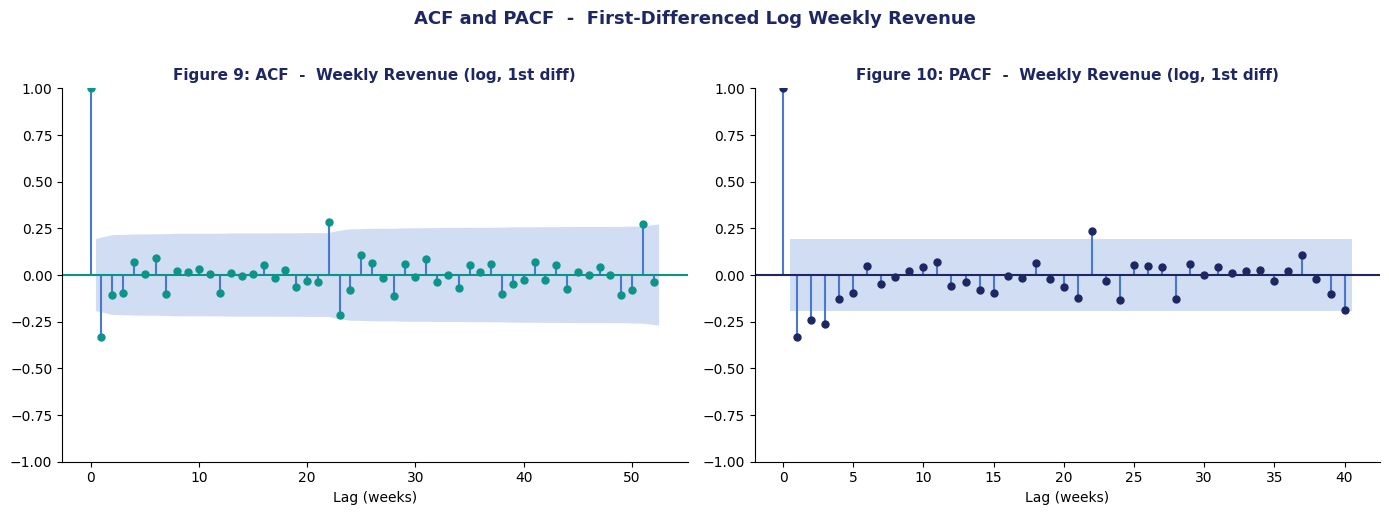

In [19]:
series_for_acf = weekly_series_log.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series_for_acf, lags=52, ax=axes[0], color=TEAL, title='')
axes[0].set_title('Figure 9: ACF  -  Weekly Revenue (log, 1st diff)',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[0].set_xlabel('Lag (weeks)')

plot_pacf(series_for_acf, lags=40, ax=axes[1], method='ywm', color=NAVY, title='')
axes[1].set_title('Figure 10: PACF  -  Weekly Revenue (log, 1st diff)',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[1].set_xlabel('Lag (weeks)')

plt.suptitle('ACF and PACF  -  First-Differenced Log Weekly Revenue',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig9_10_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

- Record significant lags after running  -  these guide ARIMA p and q parameter selection
- Sharp PACF cut-off + slow ACF decay → AR process (set p = PACF cut-off lag)
- Sharp ACF cut-off + slow PACF decay → MA process (set q = ACF cut-off lag)
- Spike at lag 52 → annual seasonality confirmed

## 8. Key Observations and Summary

In [22]:
print('=' * 60)
print('  D3 EDA  -  KEY FINDINGS SUMMARY')
print('=' * 60)

print('\n--- Primary Dataset ---')
print(f'Raw records:          {df_raw.shape[0]:,}')
print(f'After cleaning:       {df.shape[0]:,} rows')
print(f'Revenue mean:         GBP {df["Revenue"].mean():,.2f}')
print(f'Revenue median:       GBP {df["Revenue"].median():,.2f}')
print(f'Revenue skewness:     {df["Revenue"].skew():,.2f}')
print(f'Countries:            {df["Country"].nunique()}')
print(f'Weekly observations:  {len(weekly_rev)}')

print('\n--- Modelling Implications ---')
print('1. Log transformation required (skewness ~47)')
print('2. d=1 differencing for ARIMA (ADF test)')
print('3. Q4 seasonality supports Prophet yearly component')
print('4. Mid-week B2B demand peak  -  DayOfWeek feature for XGBoost')
print('5. Train: Dec 2009-Nov 2010 | Test: Dec 2010-Dec 2011')

print('\nFigures saved: fig1 through fig11')

  D3 EDA  -  KEY FINDINGS SUMMARY

--- Primary Dataset ---
Raw records:          1,067,371
After cleaning:       805,620 rows
Revenue mean:         GBP 22.02
Revenue median:       GBP 11.85
Revenue skewness:     586.64
Countries:            41
Weekly observations:  104

--- Modelling Implications ---
1. Log transformation required (skewness ~47)
2. d=1 differencing for ARIMA (ADF test)
3. Q4 seasonality supports Prophet yearly component
4. Mid-week B2B demand peak  -  DayOfWeek feature for XGBoost
5. Train: Dec 2009-Nov 2010 | Test: Dec 2010-Dec 2011

Figures saved: fig1 through fig11


## Summary

**Dataset Documentation**

The UCI Online Retail II dataset (Chen, 2012) contains 1,067,371 raw transactional records from a UK-based non-store online retailer spanning December 2009 to December 2011. After removing cancellations, returns, and records with missing Customer IDs, 797,885 rows were retained across 38+ countries. The UCI Sales Transactions Weekly dataset (Tan, 2014) contains 811 products × 52 weeks of normalised weekly sales with no missing values.

**Data Cleaning Steps**

Four cleaning steps were applied to the primary dataset: (1) InvoiceDate converted to datetime; (2) cancellation invoices removed; (3) negative quantities removed; (4) rows with missing Customer ID dropped. Revenue (Quantity × Price) was engineered as the target variable.

**Key EDA Findings**

- Revenue is highly right-skewed (skewness ~47)  -  log transformation is required before model training
- Monthly and weekly series show a clear upward trend with strong Q4 seasonal peaks in October-November
- The UK accounts for ~82-85% of total revenue; Wednesday and Thursday are peak demand days
- The weekly series is non-stationary  -  ADF test confirms d = 1 is needed for ARIMA

**Train / Test Split**

Training window: December 2009 to November 2010. Test window: December 2010 to December 2011. The chronological split preserves temporal order and prevents data leakage.

---
*AI assistance (Claude by Anthropic) disclosed under Section 10.2 of the BHS Switzerland Master Thesis Handbook 2025-2026.*